# $\alpha$-Particle Dynamics in Stellarators: ML Model Evaluation

## Overview
 
This notebook evaluates neural network (NN) flow maps for the $\alpha$-particle problem.
 
In particular, this notebook will:
1. Load trained NN flow maps from specified checkpoint files.
2. Benchmark the NN forward pass runtime.
3. Generate and compare particle trajectories using the NN flow maps versus reference solutions, supporting both one-step and recursive prediction modes.
4. Compute and visualize Poincaré sections using the NN flow maps.

## Mathematical Model

Let $B:\mathbb{R}^2\rightarrow\mathbb{R}$ be a smooth positive function bounded away from zero, and let $\epsilon\in\mathbb{R}$ be a non-negative constant. The system of ODEs 
\begin{equation*}
    \begin{split}
        \dot{v}_x &= B(x,y)\,v_y,\\
        \dot{v}_y & = -B(x,y)\,v_x,\\
        \dot{x} & = \epsilon\,v_x,\\
        \dot{y} & = \epsilon\,v_y,
    \end{split}
\end{equation*}
describes the motion of a charged particle in the magnetic field $\bm{B}:\mathbb{R}^3\rightarrow\mathbb{R}^3$ given by $\bm{B}(x,y,z) = B(x,y)\,\bm{e}_z$, where $\bm{e}_z$ is the unit vector in the $z$-direction. In this formulation, the system phase space is $4$-dimensional with coordinates $(v_x,v_y,x,y)$, which can be understood as a symmetry reduction from the full $6$-dimensional phase space $(\bm{v},\bm{x})\in\mathbb{R}^3\times\mathbb{R}^3$. The reduction stems from the translational symmetry in the $z$-direction,  $(\bm{v},\bm{x})\mapsto (\bm{v},\bm{x} + \lambda\,\bm{e}_z)$, which conserves the component $v_z$. 

The magnetic field is modeled as:
\begin{align*}
B(x,y) = B_0 + a_1\,\cos(k_{x1}\,x + k_{y1}\,y) + a_2\,\cos(k_{x2}\,x + k_{y2}\,y),
\end{align*}
where $B_0 = 1$, $ a_1 =a_2 = 0.3$ , $ k_{x_1} = 3$, $k_{y_1} = 1$, $k_{x_2} = 1$, $ k_{y_2} = 3$.


## Setup and Dependencies

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
import time
import torch

from notebook_utils.dataprocessing import AlphaParticle, AlphaParticleTrajectory, AlphaParticleDataset, batch_poincare_section
from notebook_utils.visualization import AlphaParticleVisualizer
from notebook_utils.evaluation import (
    find_latest_ckpt, load_model_from_ckpt, time_forward,
    one_step_predict, recursive_predict, batch_forward,
)

Trajectory = AlphaParticleTrajectory
Dataset = AlphaParticleDataset
viz = AlphaParticleVisualizer()

## Load Models

In [2]:
ALL_MODELS = {
    ## Thick Shell-Box collocation; preserve velocity norm 
    "IdEnf: IM uniform(0,5) h=0.1 no f(u), branch": {
        "model_name": "IdentityEnforcedSolutionMap",
        "ckpt_dir": "../../deep_learning/logs/train/runs/20250314-205553_nb5l7c/checkpoints",
    },
    "IdEnf: IM uniform(0,5) h=0.1, no branch": {
        "model_name": "IdentityEnforcedSolutionMap",
        "ckpt_dir": "../../deep_learning/logs/train/runs/20250314-205000_pytkto/checkpoints",
    },
    "IdEnf: IM uniform(0,5) h=0.1, branch": {
        "model_name": "IdentityEnforcedSolutionMap",
        "ckpt_dir": "../../deep_learning/logs/train/runs/20250314-205312_a5zsq2/checkpoints",
    },
    "Taylor1IdEnf: IM uniform(0,5) h=0.1, branch": {
        "model_name": "TaylorBasedIdentityEnforcedSolutionMap",
        "ckpt_dir": "../../deep_learning/logs/train/runs/20250314-210300_rwbn17/checkpoints",
    },
    "Taylor2IdEnf: IM uniform(0,5) h=0.1, branch": {
        "model_name": "TaylorBasedIdentityEnforcedSolutionMap",
        "ckpt_dir": "../../deep_learning/logs/train/runs/20250314-210709_5iqazp/checkpoints",
    },
    "Taylor1IdEnf: IM uniform(0,5) h=0.1, branch, identity": {
        "model_name": "TaylorBasedIdentityEnforcedSolutionMap",
        "ckpt_dir": "../../deep_learning/logs/train/runs/20250315-153213_g1sktc/checkpoints",
    },
    "Taylor2IdEnf: IM uniform(0,5) h=0.1, branch, identity": {
        "model_name": "TaylorBasedIdentityEnforcedSolutionMap",
        "ckpt_dir": "../../deep_learning/logs/train/runs/20250315-153342_uz4iqa/checkpoints",
    },
    "IdEnf: IM uniform(0,5) h=0.01, no branch, trained from scratch": {
        "model_name": "IdentityEnforcedSolutionMap",
        "ckpt_dir": "../../deep_learning/logs/train/runs/20250319-134135_b8umqb/checkpoints",
    },
    "IdEnf: IM uniform(0,5) h=0.01, no branch": {
        "model_name": "IdentityEnforcedSolutionMap",
        "ckpt_dir": "../../deep_learning/logs/train/runs/20250319-140525_coejan/checkpoints",
    },
    "IdEnf: IM uniform(0,5) h=0.01, branch": {
        "model_name": "IdentityEnforcedSolutionMap",
        "ckpt_dir": "../../deep_learning/logs/train/runs/20250316-132355_d56jnk/checkpoints",
    },
    "Taylor1IdEnf: IM uniform(0,5) h=0.01, branch": {
        "model_name": "TaylorBasedIdentityEnforcedSolutionMap",
        "ckpt_dir": "../../deep_learning/logs/train/runs/20250316-032545_bdtb5d/checkpoints",
    },
    "Taylor2IdEnf: IM uniform(0,5) h=0.01, branch": {
        "model_name": "TaylorBasedIdentityEnforcedSolutionMap",
        "ckpt_dir": "../../deep_learning/logs/train/runs/20250316-000627_ck11j6/checkpoints",
    },
    "Taylor2IdEnf: IM uniform(0,5) h=0.01, branch, trained from scratch": {
        "model_name": "TaylorBasedIdentityEnforcedSolutionMap",
        "ckpt_dir": "../../deep_learning/logs/train/runs/20250316-000436_uws6jo/checkpoints",
    },
    "Taylor2IdEnf: IM uniform(0,5) h=0.01, branch, trained for 5M steps": {
        "model_name": "TaylorBasedIdentityEnforcedSolutionMap",
        "ckpt_dir": "../../deep_learning/logs/train/runs/20250318-113641_9mawdq/checkpoints",
    },
    "Taylor1IdEnf: PINN uniform(0,5), branch": {
        "model_name": "TaylorBasedIdentityEnforcedSolutionMap",
        "ckpt_dir": "../../deep_learning/logs/train/runs/20250316-032105_8sovp6/checkpoints",
    },
    "Taylor2IdEnf: PINN uniform(0,5), branch": {
        "model_name": "TaylorBasedIdentityEnforcedSolutionMap",
        "ckpt_dir": "../../deep_learning/logs/train/runs/20250316-001706_qjxwsp/checkpoints",
    },
    "Taylor1IdEnf: IM uniform(0,5) h=0.01, branch, EBE": {
        "model_name": "TaylorBasedIdentityEnforcedSolutionMap",
        "ckpt_dir": "../../deep_learning/logs/train/runs/20250321-015954_uogpe7/checkpoints",
    },
    "Taylor2IdEnf: IM uniform(0,5) h=0.01, branch, EBE": {
        "model_name": "TaylorBasedIdentityEnforcedSolutionMap",
        "ckpt_dir": "../../deep_learning/logs/train/runs/20250321-015438_6znimy/checkpoints",
    },
    "Taylor2IdEnf: IM uniform(0,10) h=0.01, branch, EBE": {
        "model_name": "TaylorBasedIdentityEnforcedSolutionMap",
        "ckpt_dir": "../../deep_learning/logs/train/runs/20250324-233257_c4cry0/checkpoints",
    },
    "Taylor1IdEnf: IM uniform(0,5) h=0.01, branch, EBE, trained for 5M steps": {
        "model_name": "TaylorBasedIdentityEnforcedSolutionMap",
        "ckpt_dir": "../../deep_learning/logs/train/runs/20250321-121550_wrp9ja/checkpoints",
    },
    "Taylor2IdEnf: IM uniform(0,5) h=0.01, branch, EBE, trained for 5M steps": {
        "model_name": "TaylorBasedIdentityEnforcedSolutionMap",
        "ckpt_dir": "../../deep_learning/logs/train/runs/20250321-121238_f0bbt0/checkpoints",
    },
    ## Fixed epsilon model 
    "Taylor2IdEnf: IM uniform(0,5) h=0.01, branch, eps=0.05": {
        "model_name": "TaylorBasedIdentityEnforcedSolutionMap",
        "ckpt_dir": "../../deep_learning/logs/train/runs/20250320-220938_31odnn/checkpoints",
    },
    "Taylor2IdEnf: IM uniform(0,5) h=0.01, branch, eps=0.27": {
        "model_name": "TaylorBasedIdentityEnforcedSolutionMap",
        "ckpt_dir": "../../deep_learning/logs/train/runs/20250320-220436_eehuxf/checkpoints",
    },
    "Taylor2IdEnf: IM uniform(0,5) h=0.01, branch, eps=0.05, EBE": {
        "model_name": "TaylorBasedIdentityEnforcedSolutionMap",
        "ckpt_dir": "../../deep_learning/logs/train/runs/20250321-132712_b83p4k/checkpoints",
    },
    "Taylor2IdEnf: IM uniform(0,5) h=0.01, branch, eps=0.05, EBE, nondim": {
        "model_name": "TaylorBasedIdentityEnforcedSolutionMap",
        "ckpt_dir": "../../deep_learning/logs/train/runs/20250321-135621_nmjp8t/checkpoints",
    },
    ## Thin Shell-Box data (version 5)
    "T0Centered: data at 10, MSE": {
        "model_name": "T0CenteredSolutionMap",
        "ckpt_dir": "../../deep_learning/logs/train/runs/20250322-152719_twtkbo/checkpoints",
    },
    "T0Centered: data at 10, EBE": {
        "model_name": "T0CenteredSolutionMap",
        "ckpt_dir": "../../deep_learning/logs/train/runs/20250322-153443_elksku/checkpoints",
    },
    "T0Centered: data at 10 + IM normal(10,1) h=0.01, EBE": {
        "model_name": "TaylorBasedT0CenteredSolutionMap",
        "ckpt_dir": "../../deep_learning/logs/train/runs/20250322-174816_sizrf3/checkpoints",
    },
    "T0Centered: 80k data at 10, EBE": {
        "model_name": "TaylorBasedT0CenteredSolutionMap",
        "ckpt_dir": "../../deep_learning/logs/train/runs/20250323-131517_364x1a/checkpoints",
    },
    "T0Centered: 80k data at 10 + IM normal(10,1) h=0.01, EBE": {
        "model_name": "TaylorBasedT0CenteredSolutionMap",
        "ckpt_dir": "../../deep_learning/logs/train/runs/20250323-131759_uag5jp/checkpoints",
    },
}

In [3]:
SELECTED_MODELS = [
    "Taylor2IdEnf: IM uniform(0,5) h=0.01, branch, EBE, trained for 5M steps",
]

models = []
model_labels = []
for key in SELECTED_MODELS:
    ckpt_info = ALL_MODELS[key]
    ckpt_path = find_latest_ckpt(ckpt_info["ckpt_dir"])
    model, _ = load_model_from_ckpt(ckpt_path, ckpt_info["model_name"])
    print(model)
    # model.to("mps")
    # print(model.device)
    model.to(torch.float64)
    print(model.dtype)
    models.append(model)
    model_labels.append(key)

TaylorBasedIdentityEnforcedSolutionMap(
  problem: AlphaParticle(epsilon=0.15, B0=1.0, a1=0.3, a2=0.3, k_x1=3.0, k_y1=1.0, k_x2=1.0, k_y2=3.0)
  use_dimensionless: False
  problem_param_keys: ['epsilon']
  order: 2
  (loss_fn): MeanEnergyNormSquaredLoss()
  (net): PirateNet(
    (encoder1): Linear(in_features=10, out_features=1000, bias=True)
    (encoder2): Linear(in_features=10, out_features=1000, bias=True)
    (input_layer): Linear(in_features=10, out_features=1000, bias=True)
    (output_layer): BranchedMLP(
      (mlps): ModuleList(
        (0-1): 2 x MLP(
          (layers): ModuleList(
            (0-1): 2 x Linear(in_features=500, out_features=500, bias=True)
            (2): Linear(in_features=500, out_features=2, bias=False)
          )
          (activation): ELU(alpha=1.0)
        )
      )
    )
    (res_blocks): ModuleList(
      (0-1): 2 x PirateNetBlock(
        (linears): ModuleList(
          (0-2): 3 x Linear(in_features=1000, out_features=1000, bias=True)
        )

## Analysis
### 1. Runtime

Measure forward pass runtime

In [6]:
for model, label in zip(models, model_labels):
    compare = time_forward(model, nsteps_list=[0, 1, 2])
    print(f"Model: {label}")
    print(compare)

Model: Taylor2IdEnf: IM uniform(0,5) h=0.01, branch, EBE, trained for 5M steps
[----------------------------------------------- forward time -----------------------------------------------]
                                                          |  cpu: nsteps=0  |  cpu: nsteps=1  |  cpu: nsteps=2
1 threads: ---------------------------------------------------------------------------------------------------
      u: torch.Size([1, 4]), t: torch.Size([1, 1])        |      175.9      |     3154542.0   |     6378333.0 
      u: torch.Size([64, 4]), t: torch.Size([64, 1])      |      175.0      |    11811791.0   |    23749167.0 
      u: torch.Size([128, 4]), t: torch.Size([128, 1])    |      174.5      |    21413584.0   |    42574500.0 
      u: torch.Size([512, 4]), t: torch.Size([512, 1])    |      174.1      |    77016500.0   |   161008458.0 
      u: torch.Size([1024, 4]), t: torch.Size([1024, 1])  |      173.6      |   148256542.0   |   293302041.5 
      u: torch.Size([2048, 4]), t

### 2. 1-Step Predictions

Evaluate the model at different times

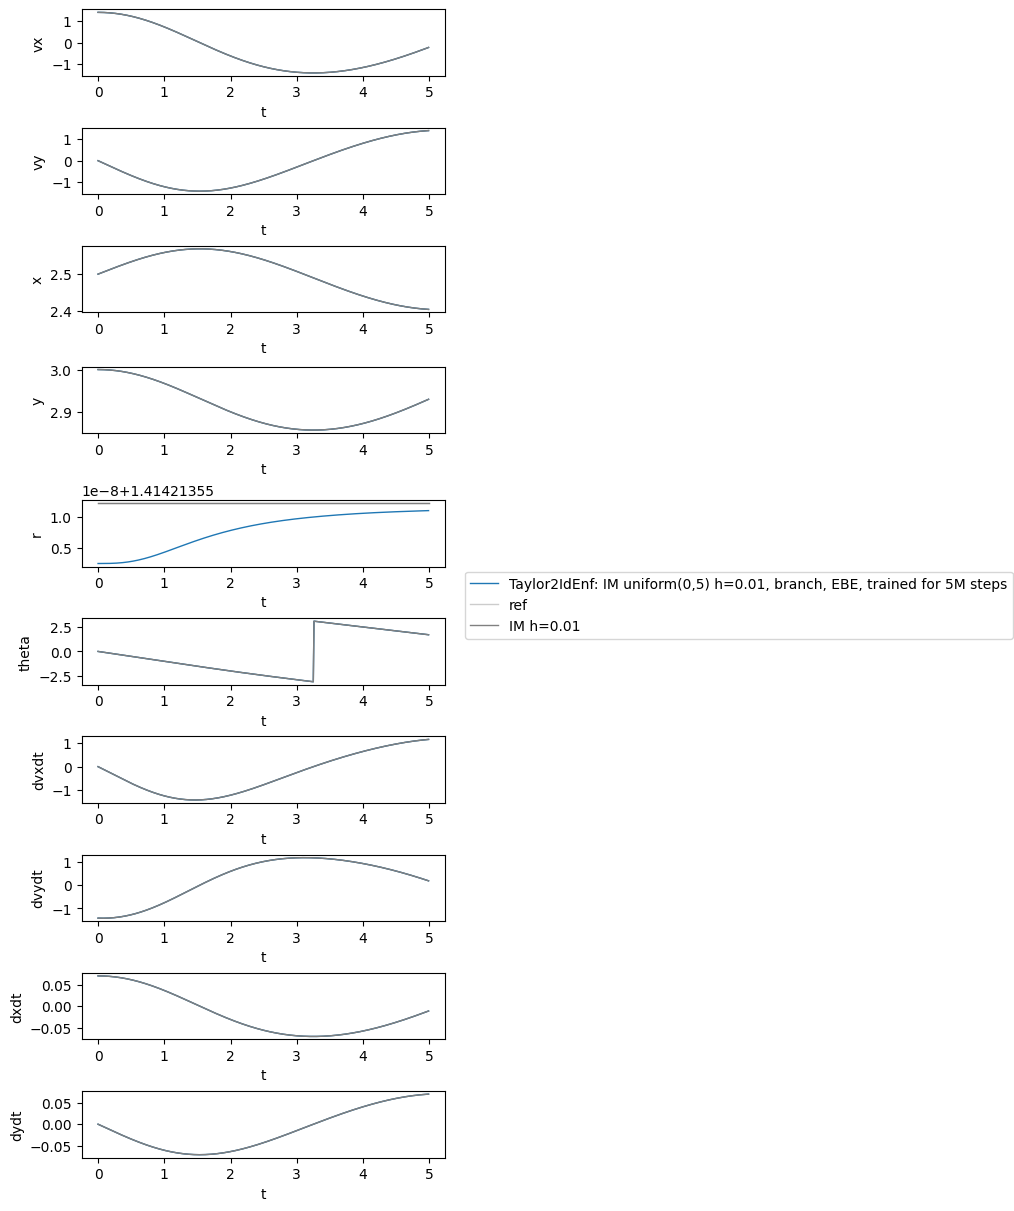

After alignment: 
	traj = AlphaParticleTrajectory(t_range=[0.0, 4.99], dt=0.01, u0=[1.41421355 0.         2.5        3.        ], states=States(problem=AlphaParticle(epsilon=0.05, a1=0.3), shape=(500, 4)))
	ref_traj = AlphaParticleTrajectory(t_range=[0.0, 4.99], dt=0.01, u0=[1.41421356 0.         2.5        3.        ], states=States(problem=AlphaParticle(epsilon=0.05, a1=0.3), shape=(500, 4)))
Taylor2IdEnf: IM uniform(0,5) h=0.01, branch, EBE, trained for 5M steps n=1 abs_traj_err = 1.0121964208472142e-08
Taylor2IdEnf: IM uniform(0,5) h=0.01, branch, EBE, trained for 5M steps n=499 abs_traj_err = 0.0010430912092398977
Taylor2IdEnf: IM uniform(0,5) h=0.01, branch, EBE, trained for 5M steps n=1 abs_traj_err_xy = 1.496311050763367e-11
Taylor2IdEnf: IM uniform(0,5) h=0.01, branch, EBE, trained for 5M steps n=499 abs_traj_err_xy = 8.21452363091426e-05
Taylor2IdEnf: IM uniform(0,5) h=0.01, branch, EBE, trained for 5M steps n=1 abs_traj_err_vxvy = 1.0121953148622801e-08
Taylor2IdEnf: IM unif

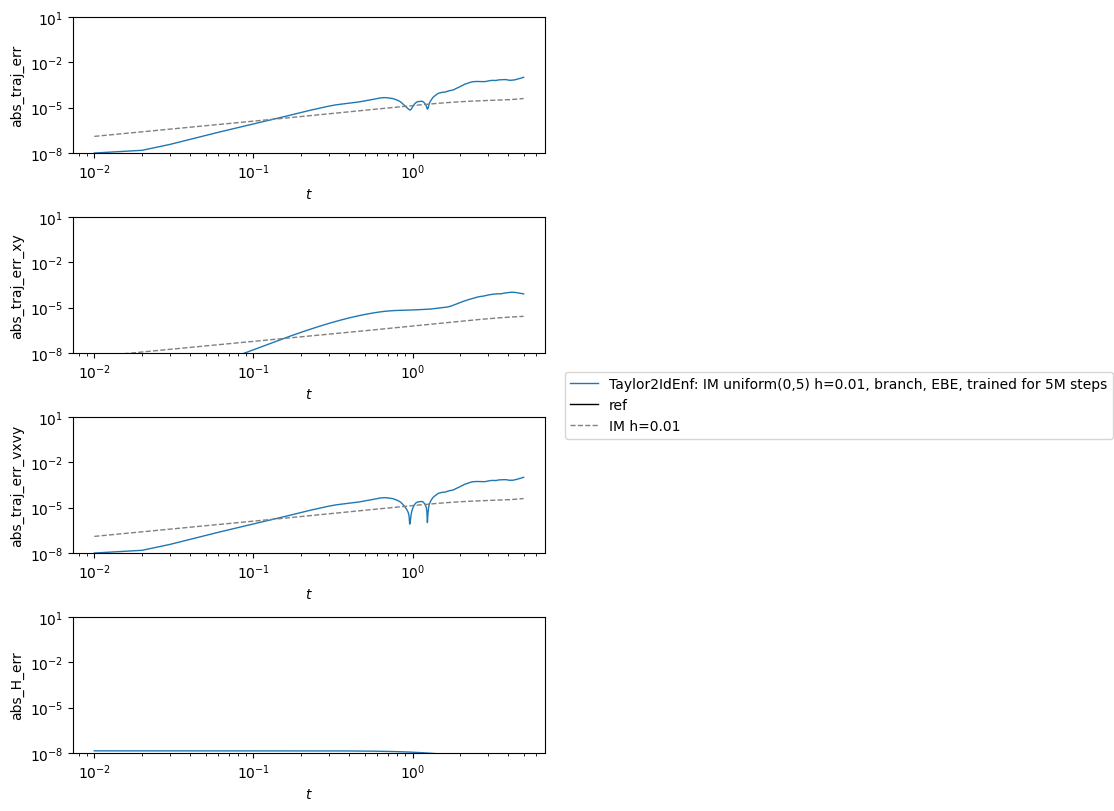

After alignment: 
	traj = AlphaParticleTrajectory(t_range=[0.0, 4.99], dt=0.01, u0=[1.41421355 0.         2.5        3.        ], states=States(problem=AlphaParticle(epsilon=0.05, a1=0.3), shape=(500, 4)))
	ref_traj = AlphaParticleTrajectory(t_range=[0.0, 4.99], dt=0.01, u0=[1.41421356 0.         2.5        3.        ], states=States(problem=AlphaParticle(epsilon=0.05, a1=0.3), shape=(500, 4)))
Taylor2IdEnf: IM uniform(0,5) h=0.01, branch, EBE, trained for 5M steps n=1 abs_traj_err = 1.2698810769585857e-07
Taylor2IdEnf: IM uniform(0,5) h=0.01, branch, EBE, trained for 5M steps n=499 abs_traj_err = 0.0010019352465508165
Taylor2IdEnf: IM uniform(0,5) h=0.01, branch, EBE, trained for 5M steps n=1 abs_traj_err_xy = 5.923248359279389e-09
Taylor2IdEnf: IM uniform(0,5) h=0.01, branch, EBE, trained for 5M steps n=499 abs_traj_err_xy = 7.96825367584453e-05
Taylor2IdEnf: IM uniform(0,5) h=0.01, branch, EBE, trained for 5M steps n=1 abs_traj_err_vxvy = 1.2684989012627985e-07
Taylor2IdEnf: IM unif

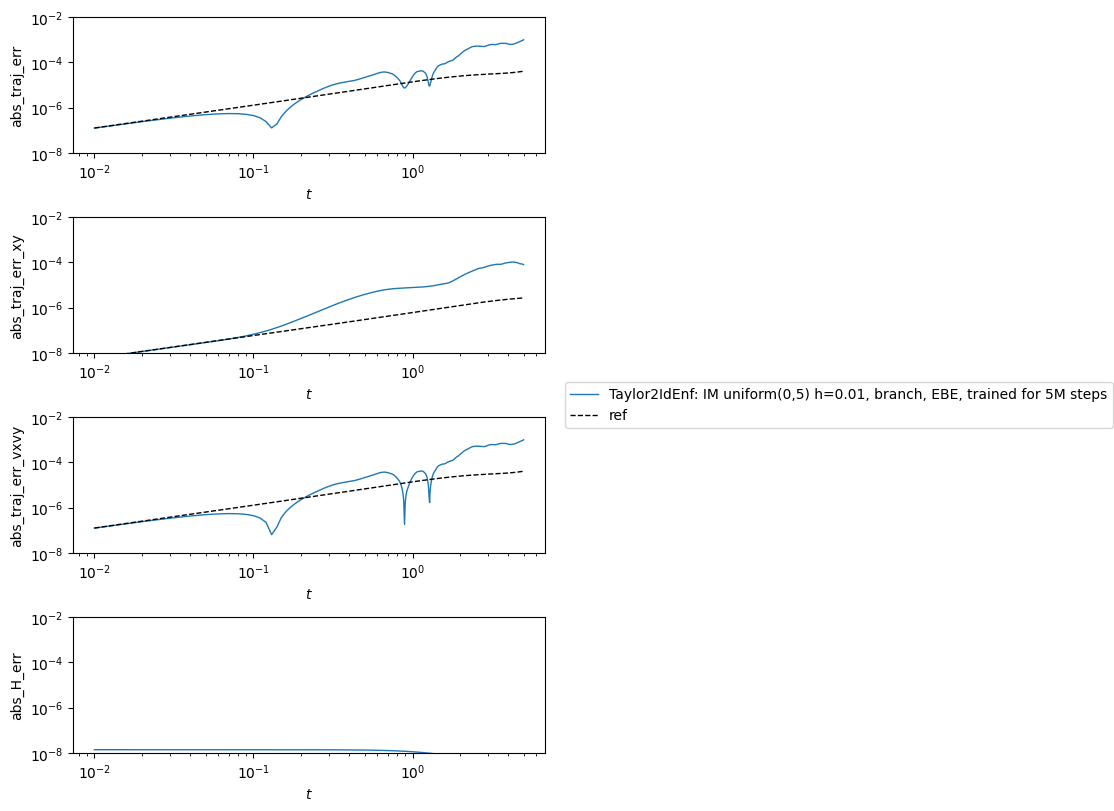

In [4]:
def trajectory_from_taylor_expansion(u0, times, p, order):
    """Generate trajectory using Taylor series expansion."""
    processor = AlphaParticle(**p)
    u = processor.compute_taylor_series(u0, times, order)
    return Trajectory.from_u(times, u, **p)

def build_trajectory_list(pred_trajs, model_labels, ref_traj, coarse_ref_traj, taylor_trajs, 
                         show_coarse_ref, show_taylor, t_list):
    """Build lists of trajectories, labels, and colors for plotting."""
    trajs = pred_trajs.copy()
    labels = model_labels.copy()
    colors = [f"C{i}" for i in range(len(model_labels))]
    
    # Add reference
    trajs.append(ref_traj.select_between(t_list.min(), t_list.max()))
    labels.append("ref")
    colors.append("black")
    
    # Add coarse reference if requested
    if show_coarse_ref and coarse_ref_traj:
        trajs.append(coarse_ref_traj.select_between(t_list.min(), t_list.max()))
        labels.append("IM h=0.01")
        colors.append("grey")
    
    # Add Taylor trajectories if requested
    if show_taylor:
        trajs.extend(taylor_trajs)
        labels.extend([f"Taylor order {i+1}" for i in range(len(taylor_trajs))])
        colors.extend(["red", "green"][:len(taylor_trajs)])
    
    return trajs, labels, colors

# Configuration
epsilon = 0.05
params = {"epsilon": epsilon}
processor = AlphaParticle(epsilon=epsilon)
ref_traj_idx = 1

# Display options
show_coarse_ref = True
show_taylor = False
taylor_orders = [1, 2]

# Load trajectories
ref_filepaths = AlphaParticle.get_reference_filepaths('default')
ref_traj = Trajectory.load_from_file(
    ref_filepaths[epsilon][ref_traj_idx]["filepath"], 
    dt=ref_filepaths[epsilon][ref_traj_idx]["dt"], **params
)
u0 = ref_traj.states.u[0]

coarse_ref_traj = None
if show_coarse_ref:
    coarse_ref_filepaths = AlphaParticle.get_reference_filepaths('implicit_midpoint_0_01')
    coarse_ref_traj = Trajectory.load_from_file(
        coarse_ref_filepaths[epsilon][ref_traj_idx]["filepath"], 
        dt=coarse_ref_filepaths[epsilon][ref_traj_idx]["dt"], **params
    )

# Generate predictions
t_list = np.arange(0, 5., 0.01)
pred_trajs = [Trajectory.from_u(t_list, one_step_predict(model, u0, t_list, params), **params) 
              for model in models]

taylor_trajs = []
if show_taylor:
    taylor_trajs = [trajectory_from_taylor_expansion(u0, t_list, params, order) 
                    for order in taylor_orders]

# Plot trajectory history
all_trajs, all_labels, all_colors = build_trajectory_list(
    pred_trajs, model_labels, ref_traj, coarse_ref_traj, taylor_trajs, 
    show_coarse_ref, show_taylor, t_list
)

viz.plot_history(
    all_trajs,
    func_dict={
        'vx': lambda u: u[:, 0], 'vy': lambda u: u[:, 1],
        'x': lambda u: u[:, 2], 'y': lambda u: u[:, 3], 
        'r': lambda u: np.sqrt(u[:, 0]**2 + u[:, 1]**2),
        'theta': lambda u: np.arctan2(u[:, 1], u[:, 0]),
        'dvxdt': lambda u: processor.compute_du(u)[:, 0],
        'dvydt': lambda u: processor.compute_du(u)[:, 1],
        'dxdt': lambda u: processor.compute_du(u)[:, 2],
        'dydt': lambda u: processor.compute_du(u)[:, 3],
    },
    xlabel='t', legend_labels=all_labels, colors=all_colors,
    show_legend=True, figsize=(10, 12),
)

# Plot errors against reference
error_trajs, error_labels, error_colors = build_trajectory_list(
    pred_trajs, model_labels, ref_traj, coarse_ref_traj, taylor_trajs, 
    show_coarse_ref, show_taylor, t_list
)
error_linestyles = ["-"] * len(model_labels) + ["-"] + (["--"] if show_coarse_ref else []) + (["-."] * len(taylor_trajs) if show_taylor else [])

viz.plot_errors(
    error_trajs, ref_traj, legend_labels=error_labels, 
    error_names=["abs_traj_err", "abs_traj_err_xy", "abs_traj_err_vxvy", "abs_H_err"], 
    show_legend=True, linestyles=error_linestyles, colors=error_colors,
    ylims=[(1e-8, 1e1)]*4, log_xscale=True, figsize=(11, 8),
)

# Plot errors against coarse reference if available
if show_coarse_ref and coarse_ref_traj:
    coarse_error_trajs, coarse_error_labels, coarse_error_colors = build_trajectory_list(
        pred_trajs, model_labels, ref_traj, None, taylor_trajs, False, show_taylor, t_list
    )
    coarse_error_linestyles = ["-"] * len(model_labels) + ["--"] + (["-."] * len(taylor_trajs) if show_taylor else [])
    
    viz.plot_errors(
        coarse_error_trajs, coarse_ref_traj, 
        error_names=["abs_traj_err", "abs_traj_err_xy", "abs_traj_err_vxvy", "abs_H_err"], 
        legend_labels=coarse_error_labels, show_legend=True, 
        linestyles=coarse_error_linestyles, colors=coarse_error_colors,
        ylims=[(1e-8, 1e-2)]*4, log_xscale=True, figsize=(11, 8), 
    )


### 3. Recursive Predictions

Repeatedly applying the model with a fixed time step (dt)

Model: Taylor2IdEnf: IM uniform(0,5) h=0.01, branch, EBE, trained for 5M steps
	dt=4.0 Recursive prediction time: 9.50e-01s
	dt=2.0 Recursive prediction time: 1.84e+00s


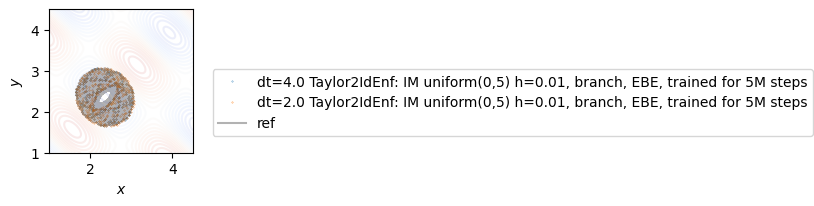

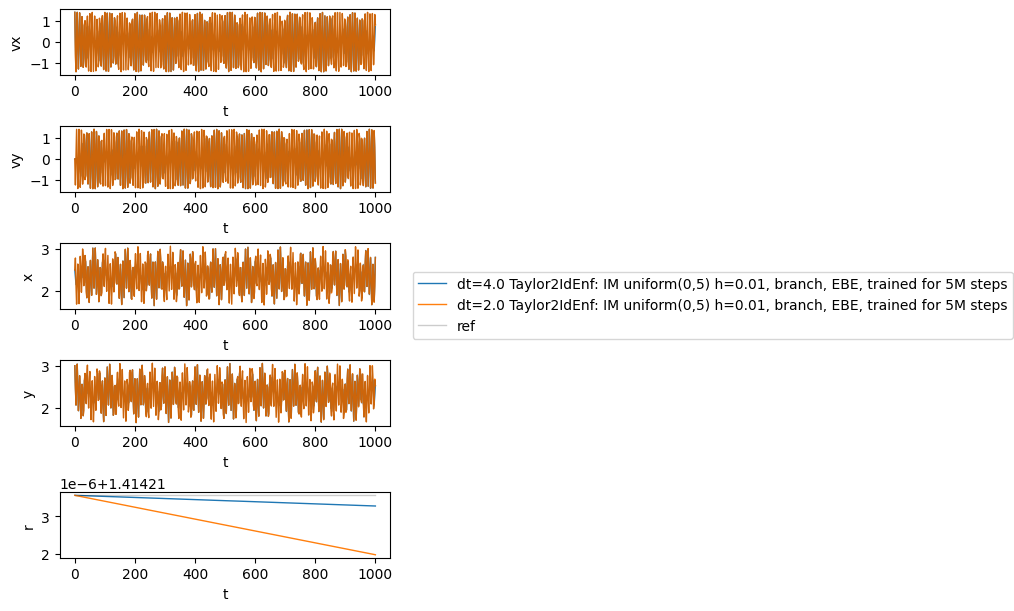

After alignment: 
	traj = AlphaParticleTrajectory(t_range=[0.0, 1000.0], dt=4.0, u0=[1.41421356 0.         2.5        3.        ], states=States(problem=AlphaParticle(epsilon=0.27, a1=0.3), shape=(251, 4)))
	ref_traj = AlphaParticleTrajectory(t_range=[0.0, 1000.0], dt=4.0, u0=[1.41421356 0.         2.5        3.        ], states=States(problem=AlphaParticle(epsilon=0.27, a1=0.3), shape=(251, 4)))
dt=4.0 Taylor2IdEnf: IM uniform(0,5) h=0.01, branch, EBE, trained for 5M steps n=1 abs_traj_err = 0.0004590436458641512
dt=4.0 Taylor2IdEnf: IM uniform(0,5) h=0.01, branch, EBE, trained for 5M steps n=250 abs_traj_err = 0.0443661050410478
dt=4.0 Taylor2IdEnf: IM uniform(0,5) h=0.01, branch, EBE, trained for 5M steps n=1 abs_traj_err_xy = 0.00034015226262271473
dt=4.0 Taylor2IdEnf: IM uniform(0,5) h=0.01, branch, EBE, trained for 5M steps n=250 abs_traj_err_xy = 0.0076186625457663896
dt=4.0 Taylor2IdEnf: IM uniform(0,5) h=0.01, branch, EBE, trained for 5M steps n=1 abs_traj_err_vxvy = 0.0003082

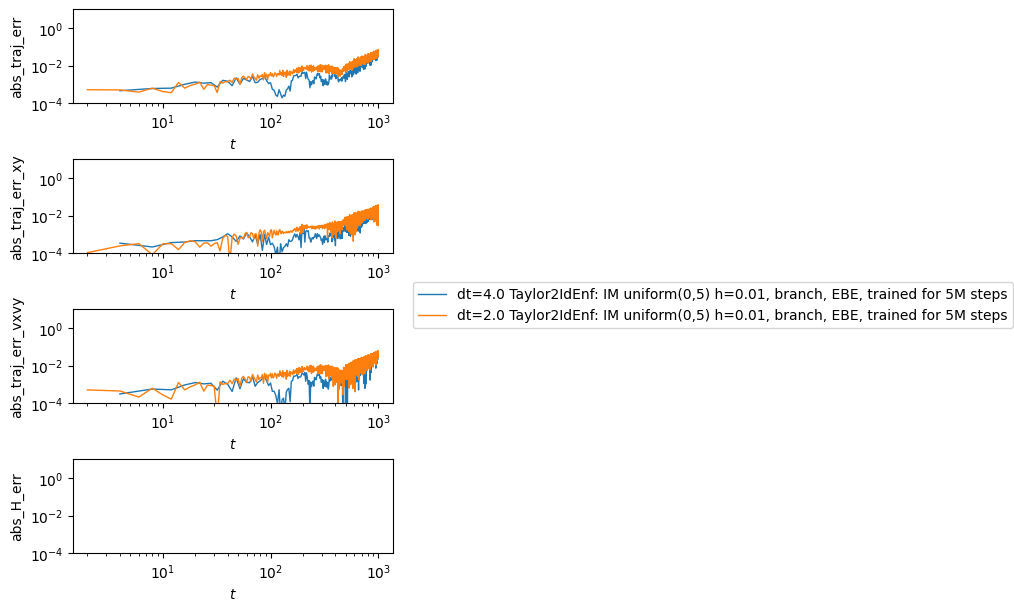

In [5]:
def build_recursive_trajectory_list(pred_trajs, labels, ref_traj, dt_list, T_end):
    """Build lists of trajectories, labels, and colors for recursive prediction plotting."""
    all_trajs = pred_trajs.copy()
    all_labels = labels.copy()
    all_colors = [f"C{i}" for i in range(len(pred_trajs))]
    
    # Add reference trajectory
    ref_traj_selected = ref_traj.select_with_interval(min(dt_list)).select_between(0, T_end)
    all_trajs.append(ref_traj_selected)
    all_labels.append("ref")
    all_colors.append("black")
    
    return all_trajs, all_labels, all_colors

# Configuration
epsilon = 0.27
params = {"epsilon": epsilon}
ref_traj_idx = 1

# Recursive prediction parameters
T_end = 1000
dt_list = [4.0, 2.0]  # Time steps for recursive evaluation
show_timing = True  # Whether to show prediction timing

# Load reference trajectory
ref_filepaths = AlphaParticle.get_reference_filepaths("default")
ref_traj = Trajectory.load_from_file(
    ref_filepaths[epsilon][ref_traj_idx]["filepath"], 
    dt=ref_filepaths[epsilon][ref_traj_idx]["dt"], **params
)
u0 = ref_traj.states.u[0]

# Generate recursive predictions: φ(φ(φ(u₀,dt),dt),dt)...
pred_trajs = []
labels = []
for model, model_label in zip(models, model_labels): 
    if show_timing:
        print(f"Model: {model_label}")
    
    for dt in dt_list:
        if show_timing:
            start = time.time()
        
        u_seq = recursive_predict(model, u0, dt, params, int(T_end//dt)+1)
        
        if show_timing:
            print(f"\tdt={dt} Recursive prediction time: {time.time()-start:.2e}s")
        
        traj = Trajectory.from_u(np.arange(len(u_seq))*dt, u_seq, **params)
        pred_trajs.append(traj)
        labels.append(f"dt={dt} {model_label}")

# Build trajectory lists for plotting
all_trajs, all_labels, all_colors = build_recursive_trajectory_list(
    pred_trajs, labels, ref_traj, dt_list, T_end
)

# Plot trajectory in xy-plane
viz.plot_xy(
    all_trajs, 
    legend_labels=all_labels, 
    show_legend=True, 
    axis_lims=[(1, 4.5), (1, 4.5)],
    figsize=(8, 4),
    linestyles=['.']*len(pred_trajs) + ['-'] 
)

# Plot trajectory history
viz.plot_history(
    all_trajs,
    func_dict={
        'vx': lambda u: u[:, 0], 'vy': lambda u: u[:, 1],
        'x': lambda u: u[:, 2], 'y': lambda u: u[:, 3], 
        'r': lambda u: np.sqrt(u[:, 0]**2 + u[:, 1]**2),
    },
    xlabel='t', legend_labels=all_labels, colors=all_colors,
    show_legend=True, figsize=(10, 6),
)

# Plot errors against reference
viz.plot_errors(
    pred_trajs, ref_traj, 
    error_names=["abs_traj_err", "abs_traj_err_xy", "abs_traj_err_vxvy", "abs_H_err"], 
    legend_labels=labels, show_legend=True, 
    ylims=[(1e-4, 1e1)]*4, log_xscale=True, figsize=(10, 6),
)


Model: Taylor2IdEnf: IM uniform(0,5) h=0.01, branch, EBE, trained for 5M steps
  dt: 5.0


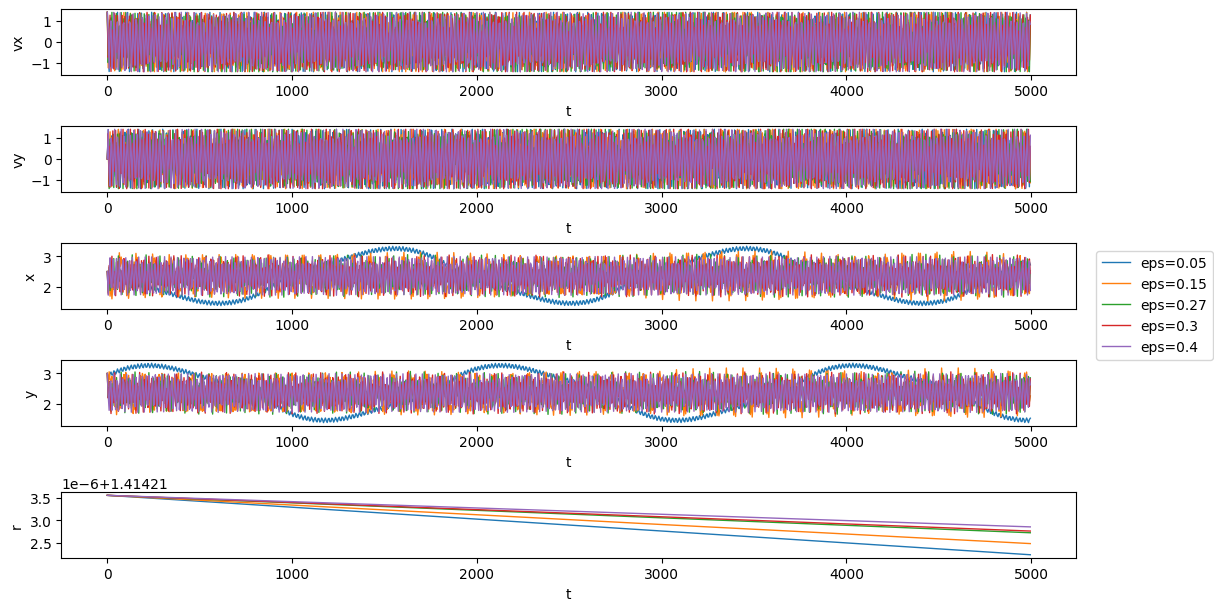

After alignment: 
	traj = AlphaParticleTrajectory(t_range=[0.0, 4995.0], dt=5.0, u0=[1.41421356 0.         2.5        3.        ], states=States(problem=AlphaParticle(epsilon=0.05, a1=0.3), shape=(1000, 4)))
	ref_traj = AlphaParticleTrajectory(t_range=[0.0, 4995.0], dt=5.0, u0=[1.41421356 0.         2.5        3.        ], states=States(problem=AlphaParticle(epsilon=0.05, a1=0.3), shape=(1000, 4)))
eps=0.05 n=1 abs_traj_err = 0.0010494525848870526
eps=0.05 n=999 abs_traj_err = 1.0049174256220532
eps=0.05 n=1 abs_traj_err_xy = 8.134659252795411e-05
eps=0.05 n=999 abs_traj_err_xy = 0.0432242320389781
eps=0.05 n=1 abs_traj_err_vxvy = 0.0010462951112426204
eps=0.05 n=999 abs_traj_err_vxvy = 1.0039873993649002
eps=0.05 n=1 abs_H_err = 1.7872854307654507e-09
eps=0.05 n=999 abs_H_err = 1.8877503313863286e-06
After alignment: 
	traj = AlphaParticleTrajectory(t_range=[0.0, 4995.0], dt=5.0, u0=[1.41421356 0.         2.5        3.        ], states=States(problem=AlphaParticle(epsilon=0.15, a1=0.3

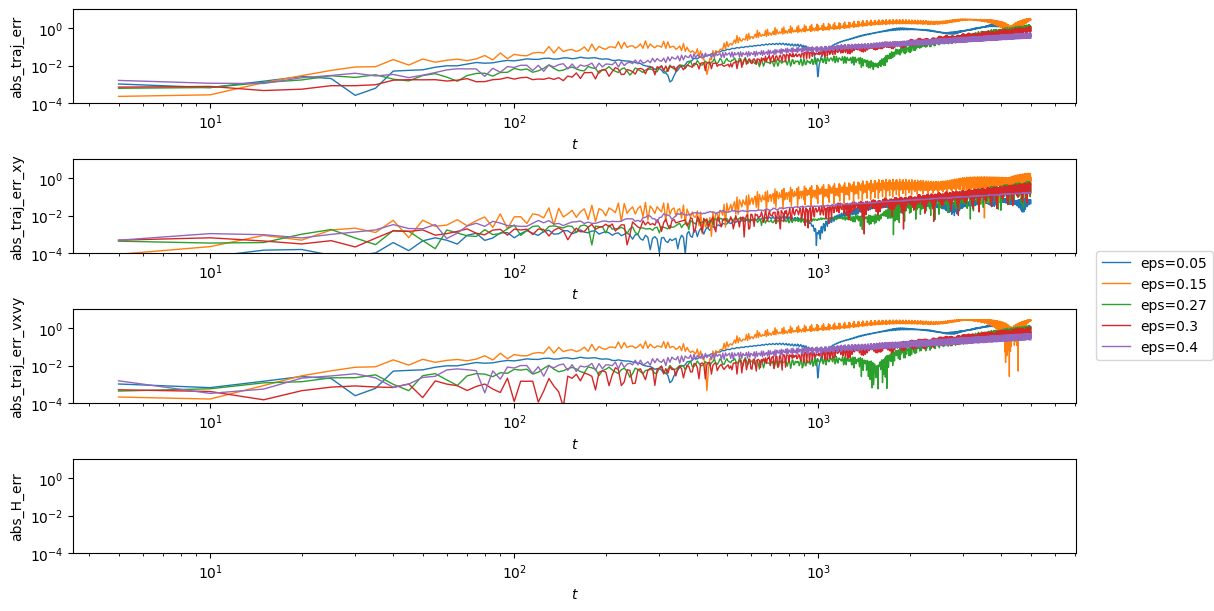

In [6]:
# Recursive Model Evaluation Across Different Epsilon Values

def build_epsilon_trajectory_list(pred_trajs, epsilon_list, ref_trajs):
    """Build lists of trajectories, labels, and colors for epsilon comparison plotting."""
    all_trajs = pred_trajs.copy()
    all_labels = [f"eps={eps}" for eps in epsilon_list]
    all_colors = [f"C{i}" for i in range(len(epsilon_list))]
    
    return all_trajs, all_labels, all_colors

# Configuration
epsilon_list = [0.05, 0.15, 0.27, 0.3, 0.4] 
ref_traj_idx = 1

# Recursive prediction parameters
T_end = 5000
dt_list = [5.0]  # Time steps for recursive evaluation
show_timing = False  # Whether to show prediction timing

# Load reference trajectories for each epsilon
ref_filepaths = AlphaParticle.get_reference_filepaths("default")
ref_trajs = [Trajectory.load_from_file(
    ref_filepaths[epsilon][ref_traj_idx]["filepath"], 
    dt=ref_filepaths[epsilon][ref_traj_idx]["dt"],
    epsilon=epsilon,
) for epsilon in epsilon_list]
u0 = ref_trajs[0].states.u[0]  # Use same initial condition for all

# Generate recursive predictions for each model and epsilon
for model, model_label in zip(models, model_labels):
    print(f"Model: {model_label}")
    
    for dt in dt_list:
        print(f"  dt: {dt}")
        
        # Generate predictions for all epsilon values
        pred_trajs = []
        for epsilon in epsilon_list:
            params = {"epsilon": epsilon}
            u_seq = recursive_predict(model, u0, dt, params, int(T_end//dt))
            traj = Trajectory.from_u(np.arange(len(u_seq))*dt, u_seq, **params)
            pred_trajs.append(traj)

        # Build trajectory lists for plotting
        all_trajs, all_labels, all_colors = build_epsilon_trajectory_list(
            pred_trajs, epsilon_list, ref_trajs
        )

        # Plot trajectory history
        viz.plot_history(
            all_trajs,
            func_dict={
                'vx': lambda u: u[:, 0], 'vy': lambda u: u[:, 1],
                'x': lambda u: u[:, 2], 'y': lambda u: u[:, 3], 
                'r': lambda u: np.sqrt(u[:, 0]**2 + u[:, 1]**2),
            },
            xlabel='t', legend_labels=all_labels, colors=all_colors,
            show_legend=True, figsize=(12, 6),
        )

        # Plot errors against reference trajectories
        viz.plot_errors(
            pred_trajs, ref_trajs, 
            error_names=["abs_traj_err", "abs_traj_err_xy", "abs_traj_err_vxvy", "abs_H_err"], 
            legend_labels=all_labels, show_legend=True, 
            ylims=[(1e-4, 1e1)]*4, log_xscale=True, figsize=(12, 6),
        )


### 4. Poincaré Sections

In [7]:
def batch_compute_poincare_section(model, u0_list, p, dt=1., T=100, tol=1e-6, reset_on_crossing=False, 
                                  method="bisection", hyperplane_func=None, direction="decreasing"):
    """
    Compute Poincare section for a batch of initial conditions.
    
    Args:
        model: Model object
        u0_list: list of np.array - Initial conditions
        p: dict - Parameters
        dt: float - Time step
        T: float - Total time
        tol: float - Tolerance
        reset_on_crossing: bool - Whether to reset on crossing
        method: str - Method for finding intersections
        hyperplane_func: callable - Function defining the hyperplane (default: vy = 0)
        direction: str - Direction of crossing ("decreasing", "increasing", "both")
        
    Returns:
        list of Trajectory objects
    """
    u0_torch = torch.tensor(np.array(u0_list), dtype=model.dtype).to(model.device)
    Phi = lambda u, t: batch_forward(model, u, t, p)
    
    # Default hyperplane function (vy = 0 for alpha particle)
    if hyperplane_func is None:
        h = lambda u: u.clone()[:, 1]  # hyperplane vy = 0
    else:
        h = lambda u: hyperplane_func(u)

    # Determine intersection parameters
    direction = 'both' if reset_on_crossing else direction
    
    intersections = batch_poincare_section(
        u0_torch, Phi, h, direction=direction, dt=dt, T=T, tol=tol, 
        reset_on_crossing=reset_on_crossing, method=method)
    
    if reset_on_crossing:
        intersections = [[(t, u) for t, u in intersections_i if u[0] > 0] 
                        for intersections_i in intersections]
    
    poincare_trajs = []
    for i, intersections_i in enumerate(intersections):
        if intersections_i:  # Only process if intersections found
            print(f"Found {len(intersections_i)} intersections for u0 = {u0_list[i]}. Average period: {np.mean(np.diff([t for t, _ in intersections_i]))}")
            traj = Trajectory.from_u(
                times=np.array([t for t, _ in intersections_i]),
                u=np.array([u for _, u in intersections_i]),
                **p)
            poincare_trajs.append(traj)
        else:
            print(f"No intersections found for u0 = {u0_list[i]}")
            poincare_trajs.append(None)

    return poincare_trajs


def generate_initial_conditions(config_type="small", n_points=None):
    """Generate initial conditions for Poincaré section analysis."""
    if config_type == "small":
        # 4 initial conditions for quick testing
        return [
            np.array([np.sqrt(2.0), 0.0, 2.5, 3.0]),
            np.array([np.sqrt(2.0), 0.0, 2.5, 3.15]),
            np.array([np.sqrt(2.0), 0.0, 2.5, 3.2]),
            np.array([np.sqrt(2.0), 0.0, 2.5, 3.25]),
        ]
    elif config_type == "line":
        # Line of initial conditions along y-axis
        return [np.array([np.sqrt(2.0), 0.0, 2.5, y]) for y in np.linspace(1.0, 4.5, n_points or 32)]
    elif config_type == "grid":
        # Grid of initial conditions
        n = int(np.sqrt(n_points or 64))
        x0_grid = np.linspace(1.5, 4, n)
        y0_grid = np.linspace(1.5, 4, n)
        return [np.array([np.sqrt(2.0), 0.0, x, y]) for x in x0_grid for y in y0_grid]
    elif config_type == "lines":
        # Two lines of initial conditions: one at x=2.5, one at x=3, both sweeping y in specified ranges
        y_line1 = np.arange(2.75, 3.55, 0.05)
        y_line2 = np.arange(3.5, 4.3, 0.05)
        return (
            [np.array([np.sqrt(2.0), 0.0, 2.5, y]) for y in y_line1] +
            [np.array([np.sqrt(2.0), 0.0, 3.0, y]) for y in y_line2]
        )
    else:
        raise ValueError(f"Unknown config_type: {config_type}")



Number of initial conditions: 32
Model: Taylor2IdEnf: IM uniform(0,5) h=0.01, branch, EBE, trained for 5M steps
  dt: 2.0
Found 599 intersections for u0 = [1.41421356 0.         2.5        2.75      ]. Average period: 8.344284481826833
Found 598 intersections for u0 = [1.41421356 0.         2.5        2.8       ]. Average period: 8.35318653547584
Found 598 intersections for u0 = [1.41421356 0.         2.5        2.85      ]. Average period: 8.356310286913285
Found 598 intersections for u0 = [1.41421356 0.         2.5        2.9       ]. Average period: 8.35168227318743
Found 599 intersections for u0 = [1.41421356 0.         2.5        2.95      ]. Average period: 8.341224380161451
Found 600 intersections for u0 = [1.41421356 0.         2.5        3.        ]. Average period: 8.322798762377197
Found 603 intersections for u0 = [1.41421356 0.         2.5        3.05      ]. Average period: 8.28509994202674
Found 608 intersections for u0 = [1.41421356 0.         2.5        3.1       ]. Ave

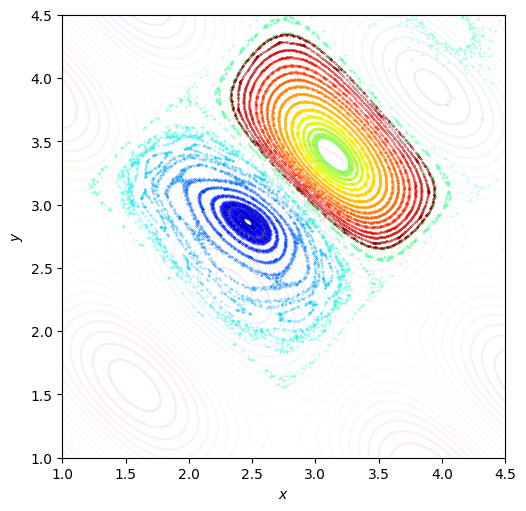

In [13]:
# Configuration
epsilon = 0.27
params = {"epsilon": epsilon}
save_path = None 

# Poincaré section parameters
T_end = 5000
dt = 2.0
tol = 1e-6
reset_on_crossing = False
method = "bisection"

# Initial conditions configuration
ic_config = "lines"  # Options: "small", "line", "grid"
n_points = None  # Number of points for line/grid (None uses defaults)

# Generate initial conditions
u0_list = generate_initial_conditions(ic_config, n_points)
print(f"Number of initial conditions: {len(u0_list)}")

# Compute and plot Poincaré sections for each model
for model, model_label in zip(models, model_labels):
    print(f"Model: {model_label}")
    print(f"  dt: {dt}")
    
    start_time = time.time()
    poincare_trajs = batch_compute_poincare_section(
        model, u0_list, params, dt=dt, T=T_end, tol=tol, 
        reset_on_crossing=reset_on_crossing, method=method
    )
    print(f"  Time elapsed: {time.time()-start_time:.2f} s")
    
    # Plot Poincaré sections
    viz.plot_xy(
        poincare_trajs, 
        linestyles='.', 
        colors=plt.cm.jet(np.linspace(0, 1, len(poincare_trajs))),
        axis_lims=[(1, 4.5), (1, 4.5)], 
        figsize=(6, 5), 
        show_legend=False,
        save_path=save_path
    )


In [14]:
# Plot using MATLAB
viz.plot_xy_matlab(
        poincare_trajs,
        linestyles='', 
        marker='o', 
        markersize=0.4,
        colors=plt.cm.jet(np.linspace(0, 1, len(poincare_trajs))),
        axis_lims=[(1, 4.5), (1, 4.5)], 
        figsize=(5, 4), 
        # show_legend=False,
        title=r"Poincar\'{e} section $\epsilon=0.27$",
        save_path=f"./out/alphaparticle/eps=2.7e-1/poincare32_model_dt_2_T_5000.pdf"
    )

Current figure size: 5.0" x 4.0"
New figure size: 3.0" x 2.4"
Saved figure as: ./out/alphaparticle/eps=2.7e-1/poincare32_model_dt_2_T_5000.pdf and ./out/alphaparticle/eps=2.7e-1/poincare32_model_dt_2_T_5000.fig
